# PROYECTO FINAL — Limpieza, Transformación y Análisis de Datos con Pandas
## Caso Empresarial: Mundial FIFA 2026 — Estrategias de Marketing para una Marca de Snacks
---
**Integrantes:**
- Diego Alejandro Escobar Barahona
- Daniella Marissa Navarro Araniva
**Repositorio:**
---

## FASE 1:Carga de Datos

In [36]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuración global de gráficos
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


In [37]:
# Carga del dataset desde CSV
RUTA_DATOS = '../data/encuesta_snacks_mundial_2026_guatemala_2500_respuestas.csv'

df_raw = pd.read_csv(RUTA_DATOS)

print(f'Dataset cargado exitosamente.')
print(f'Dimensiones: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
df_raw.head(3)

Dataset cargado exitosamente.
Dimensiones: 2500 filas × 26 columnas


,EncuestaID,FechaEncuesta,HoraEncuesta,RangoEdad,Genero,Departamento,Municipio,Ocupacion,FrecuenciaConsumoSnacks,LugarCompraSnacks,...,PagaMasEdicionMundial,PlaneaVerMundial2026,SeleccionApoya,CompraDisenoSeleccion,SeleccionInfluyeCompra,JugadoresInfluyentes,TipoPublicidadAtractiva,PromocionPreferida,CompraTarjetasColeccionables,CampaniaMasProbableCompra
0,1,2026-04-15,09:46:21,55 años o más,Femenino,Guatemala,Santa Catarina Pinula,Jubilado,Varias veces al mes,Aplicación de delivery,...,Sí,Sí,Portugal,Probablemente sí,Portugal,Kylian Mbappé; Cristiano Ronaldo; Neymar Jr.,Una selección nacional,Sorteo de viajes,Sí,Edición Francia
1,2,2026-01-26,08:45:33,18 - 24 años,Masculino,Guatemala,Santa Catarina Pinula,Empresario,1 a 2 veces por semana,Supermercado,...,Sí,Sí,Portugal,Probablemente no,Suecia,Cristiano Ronaldo; Kylian Mbappé; Christian Pu...,Una selección nacional,Producto gratis,Sí,Edición Brasil
2,3,2026-04-22,22:23:58,35 - 44 años,Masculino,Alta Verapaz,Alta Verapaz,Estudiante,Varias veces al mes,Kiosco escolar/universitario,...,Sí,Sí,España,Probablemente sí,Portugal,Cristiano Ronaldo; Federico Valverde,Un jugador famoso,Descuento directo,No,Edición con tarjetas coleccionables


## FASE 2: Exploración Inicial

In [38]:
# Tipos de datos y valores no nulos
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   EncuestaID                    2500 non-null   int64
 1   FechaEncuesta                 2500 non-null   str  
 2   HoraEncuesta                  2500 non-null   str  
 3   RangoEdad                     2500 non-null   str  
 4   Genero                        2500 non-null   str  
 5   Departamento                  2500 non-null   str  
 6   Municipio                     2438 non-null   str  
 7   Ocupacion                     2463 non-null   str  
 8   FrecuenciaConsumoSnacks       2500 non-null   str  
 9   LugarCompraSnacks             2470 non-null   str  
 10  ConQuienVePartidos            2500 non-null   str  
 11  GastoSnacksPartido            2500 non-null   str  
 12  SnacksSeleccionados           2500 non-null   str  
 13  SaborPreferido                2475 non-null 

In [39]:
# Resumen de columnas con valores nulos
nulos = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
print('Columnas con valores nulos:')
resumen_nulos[resumen_nulos['Nulos'] > 0]

Columnas con valores nulos:


,Nulos,% del total
Municipio,62,2.48
Ocupacion,37,1.48
LugarCompraSnacks,30,1.20
SaborPreferido,25,1.00
PrecioAdecuado,25,1.00
SeleccionInfluyeCompra,25,1.00


In [40]:
# Detección de duplicados
duplicados = df_raw.duplicated().sum()
print(f'Registros duplicados encontrados: {duplicados}')

# Distribución general de variables categóricas clave
print('\nDistribución por Rango de Edad:')
print(df_raw['RangoEdad'].value_counts())

print('\nDistribución por Género:')
print(df_raw['Genero'].value_counts())

Registros duplicados encontrados: 12

Distribución por Rango de Edad:
RangoEdad
25 - 34 años        735
18 - 24 años        582
35 - 44 años        460
45 - 54 años        310
Menos de 18 años    242
55 años o más       171
Name: count, dtype: int64

Distribución por Género:
Genero
Masculino                1215
Femenino                 1211
Prefiero no indicarlo      74
Name: count, dtype: int64


## FASE 3: Limpieza de Datos

In [41]:
# Se crea una copia del trabajo para no alterar el dataset original
df = df_raw.copy()

# 3.1 Eliminar filas duplicadas
df = df.drop_duplicates()
print(f'Registros tras eliminar duplicados: {len(df)}')

#  Rellenamos valores nulos en columnas que tienen categorias
df['Municipio'] = df['Municipio'].fillna('No especificado')
df['Ocupacion'] = df['Ocupacion'].fillna('No especificado')
df['LugarCompraSnacks'] = df['LugarCompraSnacks'].fillna('No especificado')
df['SaborPreferido'] = df['SaborPreferido'].fillna('No especificado')
df['PrecioAdecuado'] = df['PrecioAdecuado'].fillna('No especificado')
df['SeleccionInfluyeCompra'] = df['SeleccionInfluyeCompra'].fillna('No especificado')

print('Valores nulos tratados.')

# corregimos errores como espacios extra y mayusculas en SaborPreferido
def limpiar_texto(valor):
    if pd.isna(valor):
        return valor
    return valor.strip().title()

df['SaborPreferido'] = df['SaborPreferido'].apply(limpiar_texto)

# normalizamos las selecciones
def limpiar_seleccion(valor):
    if pd.isna(valor):
        return valor
    return valor.strip().title()

df['SeleccionInfluyeCompra'] = df['SeleccionInfluyeCompra'].apply(limpiar_seleccion)
df['SeleccionApoya'] = df['SeleccionApoya'].apply(limpiar_seleccion)

# Verificacion final
print(f'\nRegistros finales en el dataset limpio: {len(df)}')
print(f'Nulos restantes: {df.isnull().sum().sum()}')

Registros tras eliminar duplicados: 2488
Valores nulos tratados.

Registros finales en el dataset limpio: 2488
Nulos restantes: 0


In [42]:
# Convertimos FechaEncuesta a tipo datetime
df['FechaEncuesta'] = pd.to_datetime(df['FechaEncuesta'], errors='coerce')

# 3.5 Verificamos valores unicos tras la limpieza
print('SaborPreferido (tras limpieza):')
print(df['SaborPreferido'].value_counts())

SaborPreferido (tras limpieza):
SaborPreferido
Queso                 427
Picante Chapín        416
Barbacoa              377
Jalapeño              307
Limón                 278
Chocolate             210
Salado Tradicional    195
Dulce                 140
Caramelo              113
No Especificado        25
Name: count, dtype: int64


## FASE 4: Transformación de Datos

In [43]:
# rango de edades que se analizara 
orden_edad = ['Menos de 18 años', '18 - 24 años', '25 - 34 años',
              '35 - 44 años', '45 - 54 años', '55 años o más']
df['RangoEdad'] = pd.Categorical(df['RangoEdad'], categories=orden_edad, ordered=True)

# Segmento generacional
def asignar_segmento(edad):
    mapa = {
        'Menos de 18 años': 'Generación Z Joven',
        '18 - 24 años': 'Generación Z',
        '25 - 34 años': 'Millennials',
        '35 - 44 años': 'Generación X Joven',
        '45 - 54 años': 'Generación X Mayor',
        '55 años o más': 'Baby Boomers'
    }
    return mapa.get(str(edad), 'No especificado')

df['SegmentoGeneracional'] = df['RangoEdad'].apply(asignar_segmento)

# Categoria de gasto por partido
def categorizar_gasto(gasto):
    categorias = {
        'Menos de Q25': 'Bajo',
        'Q25 - Q50': 'Medio',
        'Q51 - Q100': 'Medio-Alto',
        'Q101 - Q150': 'Alto',
        'Más de Q150': 'Premium'
    }
    return categorias.get(str(gasto), 'No especificado')

df['CategoriaGasto'] = df['GastoSnacksPartido'].apply(categorizar_gasto)

#  Intención de compra (variable binaria)
df['IntencionCompraBinaria'] = df['CompraDisenoSeleccion'].apply(
    lambda x: 1 if str(x) in ['Definitivamente sí', 'Probablemente sí'] else 0
)

# Expandimos snacks a formato largo para análisis individual
def expandir_multirespuesta(serie, separador=';'):
    todos = []
    for val in serie.dropna():
        for item in val.split(separador):
            todos.append(item.strip())
    return Counter(todos)

conteo_snacks = expandir_multirespuesta(df['SnacksSeleccionados'])
conteo_jugadores = expandir_multirespuesta(df['JugadoresInfluyentes'])

print('Transformaciones aplicadas correctamente.')
print(f'Nuevas columnas: SegmentoGeneracional, CategoriaGasto, IntencionCompraBinaria')
df[['RangoEdad','SegmentoGeneracional','GastoSnacksPartido','CategoriaGasto','IntencionCompraBinaria']].head(5)

Transformaciones aplicadas correctamente.
Nuevas columnas: SegmentoGeneracional, CategoriaGasto, IntencionCompraBinaria


,RangoEdad,SegmentoGeneracional,GastoSnacksPartido,CategoriaGasto,IntencionCompraBinaria
0,55 años o más,Baby Boomers,Q25 - Q50,Medio,1
1,18 - 24 años,Generación Z,Q51 - Q100,Medio-Alto,0
2,35 - 44 años,Generación X Joven,Q51 - Q100,Medio-Alto,1
3,25 - 34 años,Millennials,Q25 - Q50,Medio,0
4,25 - 34 años,Millennials,Q51 - Q100,Medio-Alto,0


## FASE 5: Análisis y Construcción de Indicadores

In [44]:
# KPI 1: Tasa de intención de compra positiva
tasa_intencion = df['IntencionCompraBinaria'].mean() * 100

# KPI 2: % que planea ver el Mundial 2026
tasa_mundial = (df['PlaneaVerMundial2026'] == 'Sí').mean() * 100

# KPI 3: % dispuesto a pagar más por edición Mundial
tasa_precio_premium = (df['PagaMasEdicionMundial'] == 'Sí').mean() * 100

# KPI 4: % interesado en tarjetas coleccionables
tasa_coleccionables = (df['CompraTarjetasColeccionables'] == 'Sí').mean() * 100

print('-' * 55)
print('       INDICADORES CLAVE DE NEGOCIO (KPIs)')
print('-' * 55)
print(f'  Intención de compra positiva  : {tasa_intencion:.1f}%')
print(f'  Planea ver el Mundial 2026    : {tasa_mundial:.1f}%')
print(f'  Acepta precio premium edición : {tasa_precio_premium:.1f}%')
print(f'  Interés en coleccionables     : {tasa_coleccionables:.1f}%')
print('-' * 55)

-------------------------------------------------------
       INDICADORES CLAVE DE NEGOCIO (KPIs)
-------------------------------------------------------
  Intención de compra positiva  : 59.1%
  Planea ver el Mundial 2026    : 87.9%
  Acepta precio premium edición : 62.1%
  Interés en coleccionables     : 61.7%
-------------------------------------------------------


## FASE 6: Generación de Reportes

### Reporte 1: Perfil Demográfico

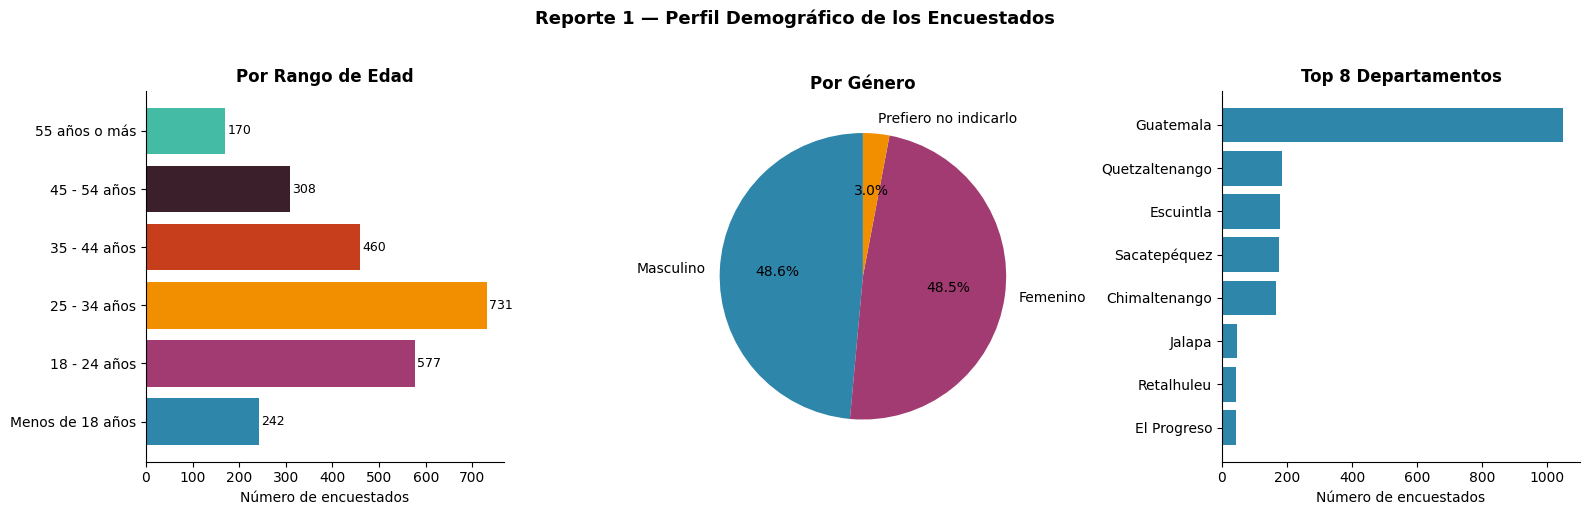

 Reporte 1 guardado.


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Reporte 1 — Perfil Demográfico de los Encuestados', fontsize=13, fontweight='bold', y=1.02)

COLORES = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4', '#E94F37']

# Rango de edad
edad_orden = df['RangoEdad'].value_counts().reindex(orden_edad)  # contamos los encuestados por rango de edad
axes[0].barh(edad_orden.index, edad_orden.values, color=COLORES[:len(edad_orden)])
axes[0].set_title('Por Rango de Edad', fontweight='bold')
axes[0].set_xlabel('Número de encuestados')
for i, v in enumerate(edad_orden.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# Género
genero_counts = df['Genero'].value_counts()  # contamos la cantidad de personas por genero
axes[1].pie(genero_counts.values, labels=genero_counts.index,
            autopct='%1.1f%%', colors=COLORES[:3], startangle=90)
axes[1].set_title('Por Género', fontweight='bold')

# Top 8 departamentos
top_dptos = df['Departamento'].value_counts().head(8) # obtenemos los 8 departamentos con mas respuestas
axes[2].barh(top_dptos.index[::-1], top_dptos.values[::-1], color='#2E86AB')
axes[2].set_title('Top 8 Departamentos', fontweight='bold')
axes[2].set_xlabel('Número de encuestados')

plt.tight_layout()
plt.savefig('../images/reporte_01_perfil_demografico.png', dpi=130, bbox_inches='tight')
plt.show()
print(' Reporte 1 guardado.')

### Reporte 2: Frecuencia de Consumo de Snacks

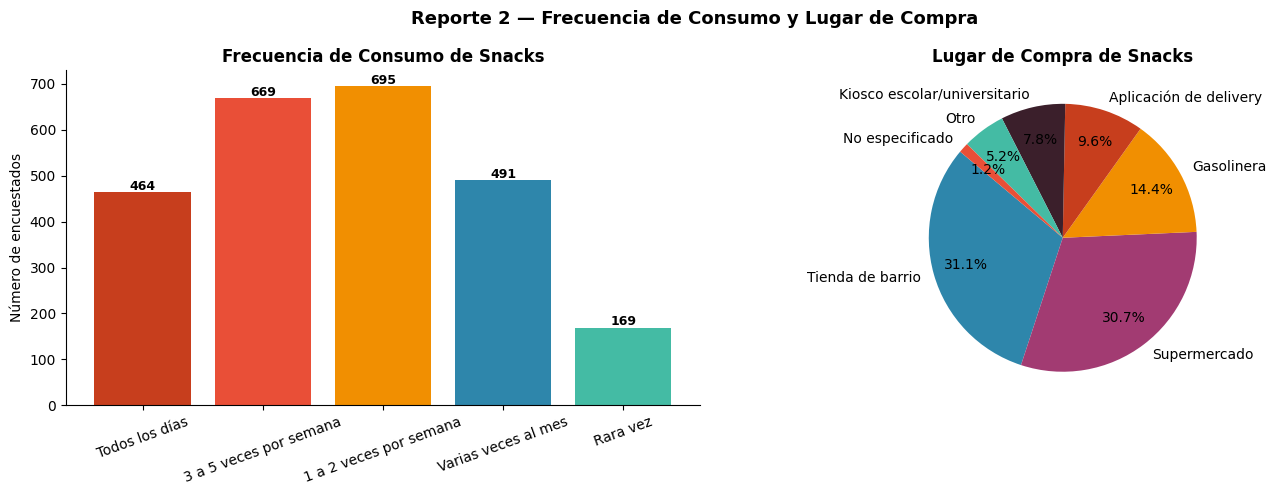

Reporte 2 guardado.


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Reporte 2 — Frecuencia de Consumo y Lugar de Compra', fontsize=13, fontweight='bold')

# Frecuencia de consumo
orden_freq = ['Todos los días', '3 a 5 veces por semana', '1 a 2 veces por semana', # definimos el orden en que queremos mostrar las categorias
              'Varias veces al mes', 'Rara vez']
freq_counts = df['FrecuenciaConsumoSnacks'].value_counts().reindex(orden_freq)  # contamos cuantas respuestas hay por cada frecuencia
colores_freq = ['#C73E1D', '#E94F37', '#F18F01', '#2E86AB', '#44BBA4']
bars = axes[0].bar(freq_counts.index, freq_counts.values, color=colores_freq)
axes[0].set_title('Frecuencia de Consumo de Snacks', fontweight='bold')
axes[0].set_ylabel('Número de encuestados')
axes[0].tick_params(axis='x', rotation=20)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha='center', fontsize=9, fontweight='bold')

# Lugar de compra
lugar_counts = df['LugarCompraSnacks'].value_counts() # contamos la cantidad de respuestas por lugar de compra
wedges, texts, autotexts = axes[1].pie(
    lugar_counts.values, labels=lugar_counts.index,
    autopct='%1.1f%%', colors=COLORES[:len(lugar_counts)],
    startangle=140, pctdistance=0.75
)
axes[1].set_title('Lugar de Compra de Snacks', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/reporte_02_frecuencia_consumo.png', dpi=130, bbox_inches='tight')
plt.show()
print('Reporte 2 guardado.')

### Reporte 3 — Ranking de Snacks

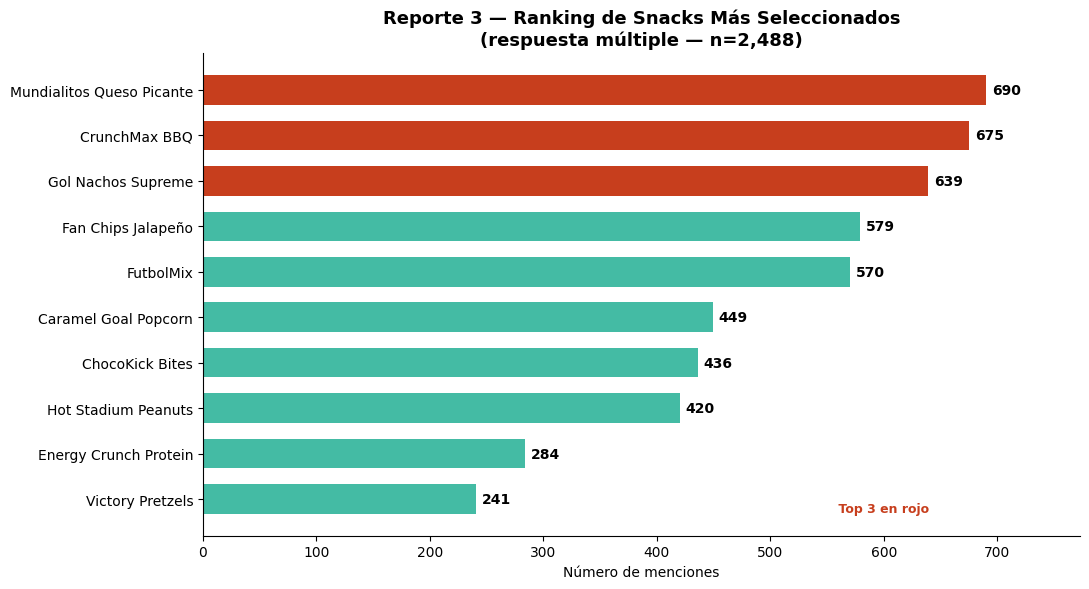

 Reporte 3 guardado.
                        Snack  Menciones  % del total
1   Mundialitos Queso Picante        690         27.7
2               CrunchMax BBQ        675         27.1
3          Gol Nachos Supreme        639         25.7
4          Fan Chips Jalapeño        579         23.3
5                   FutbolMix        570         22.9
6        Caramel Goal Popcorn        449         18.0
7             ChocoKick Bites        436         17.5
8         Hot Stadium Peanuts        420         16.9
9       Energy Crunch Protein        284         11.4
10           Victory Pretzels        241          9.7


In [58]:
fig, ax = plt.subplots(figsize=(11, 6))

top_snacks = pd.Series(conteo_snacks).sort_values(ascending=True).tail(10) # obtenemos los 10 snacks con mayor cantidad de menciones
colores_snacks = ['#44BBA4' if i < 7 else '#C73E1D' for i in range(len(top_snacks))]

bars = ax.barh(top_snacks.index, top_snacks.values, color=colores_snacks, height=0.65)
ax.set_title('Reporte 3 — Ranking de Snacks Más Seleccionados\n(respuesta múltiple — n=2,488)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Número de menciones')

for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, max(top_snacks.values) * 1.12)
ax.annotate(' Top 3 en rojo', xy=(0.72, 0.05), xycoords='axes fraction', fontsize=9,
            color='#C73E1D', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/reporte_03_ranking_snacks.png', dpi=130, bbox_inches='tight')
plt.show()
print(' Reporte 3 guardado.')

# Tabla resumen
df_snacks_ranking = pd.DataFrame(list(conteo_snacks.items()), columns=['Snack', 'Menciones']) # convertimos el diccionario de snacks en un dataframe
df_snacks_ranking = df_snacks_ranking.sort_values('Menciones', ascending=False).reset_index(drop=True) # ordenamos los snacks de mayor a menor cantidad 
df_snacks_ranking.index += 1    # iniciamos la numeracion desde 1
df_snacks_ranking['% del total'] = (df_snacks_ranking['Menciones'] / len(df) * 100).round(1) # calculamos el porcentaje de cada snack 
print(df_snacks_ranking.head(10).to_string()) # mostramos los 10 snacks con mas menciones

### Reporte 4: Análisis de Precios

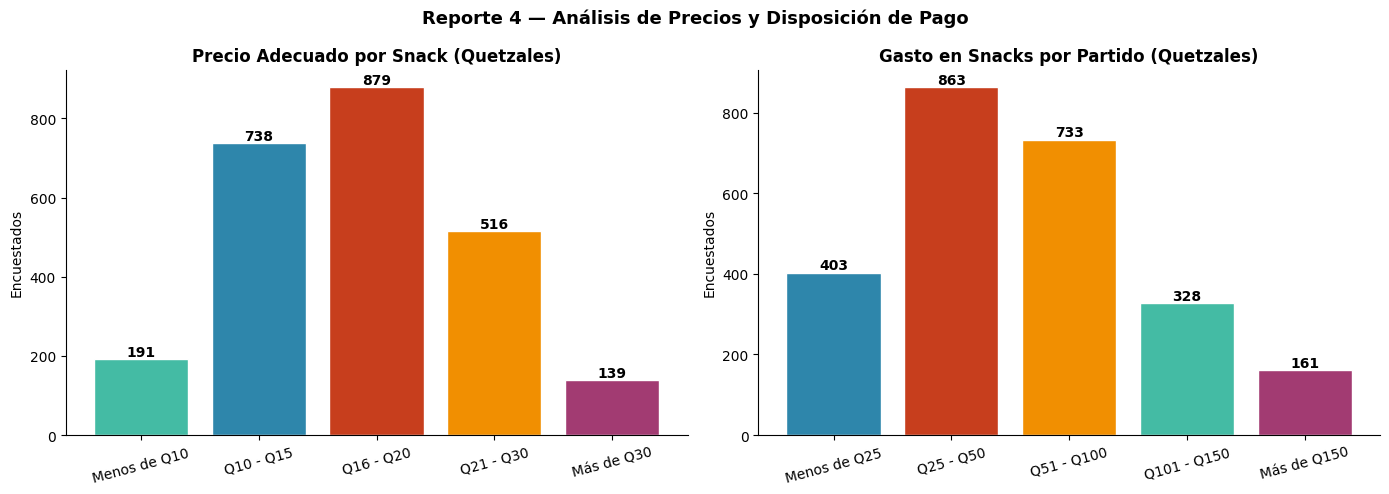

 Precio más aceptado por unidad: Q16 - Q20 (879 respuestas)
 Gasto típico por partido: Q25 - Q50 (863 respuestas)
 Disposición a pagar precio premium (edición Mundial): 62.1%


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Reporte 4 — Análisis de Precios y Disposición de Pago', fontsize=13, fontweight='bold')

# Precio adecuado por unidad
orden_precio = ['Menos de Q10', 'Q10 - Q15', 'Q16 - Q20', 'Q21 - Q30', 'Más de Q30'] # definimos el orden de las categorias de precio
precio_counts = df['PrecioAdecuado'].value_counts().reindex(orden_precio).fillna(0) # contamos las respuestas para cada rango de precio
colores_precio = ['#44BBA4', '#2E86AB', '#C73E1D', '#F18F01', '#A23B72']
bars = axes[0].bar(precio_counts.index, precio_counts.values, color=colores_precio, edgecolor='white')
axes[0].set_title('Precio Adecuado por Snack (Quetzales)', fontweight='bold')
axes[0].set_ylabel('Encuestados')
axes[0].tick_params(axis='x', rotation=15)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')

# Gasto por partido
orden_gasto = ['Menos de Q25', 'Q25 - Q50', 'Q51 - Q100', 'Q101 - Q150', 'Más de Q150'] # definimos el orden de las categorias de gasto
gasto_counts = df['GastoSnacksPartido'].value_counts().reindex(orden_gasto).fillna(0) # contamos las respuestas para cada rango de gasto
axes[1].bar(gasto_counts.index, gasto_counts.values, color=['#2E86AB','#C73E1D','#F18F01','#44BBA4','#A23B72'], edgecolor='white')
axes[1].set_title('Gasto en Snacks por Partido (Quetzales)', fontweight='bold')
axes[1].set_ylabel('Encuestados')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(gasto_counts.values):
    axes[1].text(i, v + 8, str(int(v)), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/reporte_04_analisis_precios.png', dpi=130, bbox_inches='tight')
plt.show()

precio_modal = precio_counts.idxmax() # obtenemos el rango de precio con mas respuestas
gasto_modal = gasto_counts.idxmax() # obtenemos el rango de gasto mas frecuente
print(f' Precio más aceptado por unidad: {precio_modal} ({int(precio_counts.max())} respuestas)')
print(f' Gasto típico por partido: {gasto_modal} ({int(gasto_counts.max())} respuestas)')
print(f' Disposición a pagar precio premium (edición Mundial): {tasa_precio_premium:.1f}%')

### Reporte 5: Selecciones con Mayor Influencia en Compra

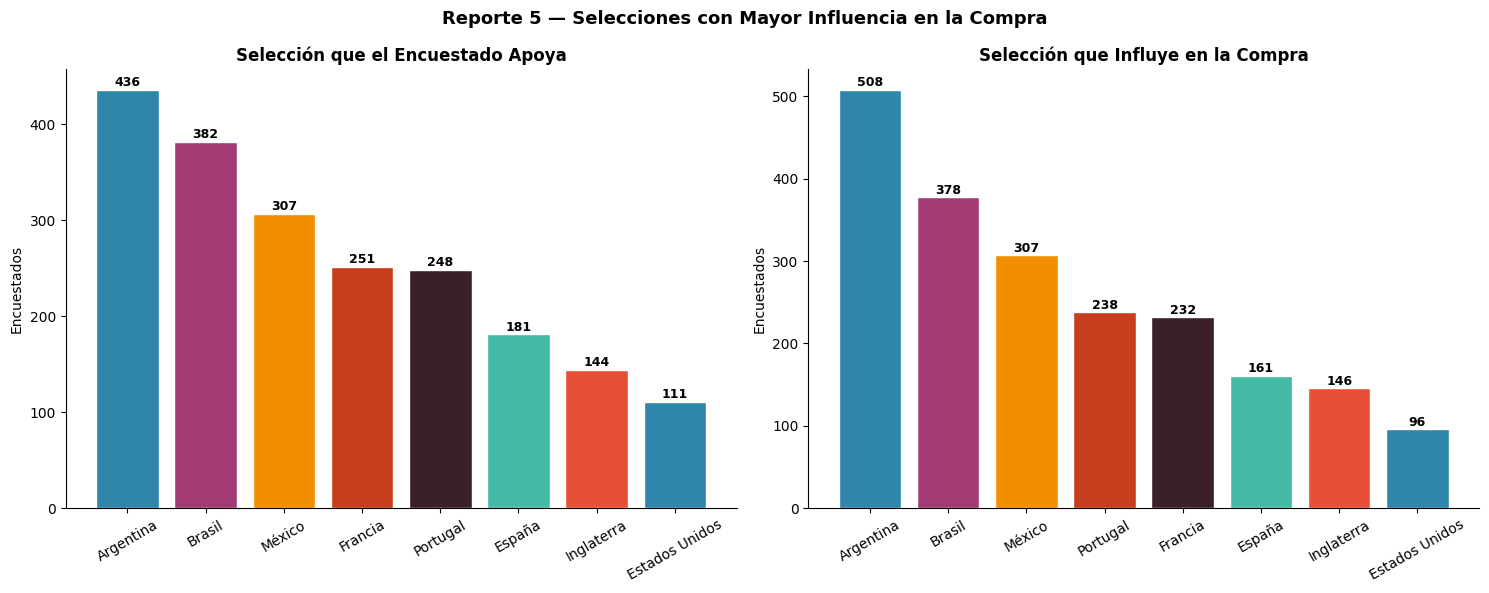

 Reporte 5 guardado.


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Reporte 5 — Selecciones con Mayor Influencia en la Compra', fontsize=13, fontweight='bold')

# Selección que el encuestado apoya
top_apoya = df['SeleccionApoya'].value_counts().head(8) # obtenemos las 8 selecciones con mas apoyo
axes[0].bar(top_apoya.index, top_apoya.values, color=COLORES[:8], edgecolor='white')
axes[0].set_title('Selección que el Encuestado Apoya', fontweight='bold')
axes[0].set_ylabel('Encuestados')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(top_apoya.values):
    axes[0].text(i, v + 4, str(v), ha='center', fontsize=9, fontweight='bold')

# Selección que influye en la compra
top_influye = df['SeleccionInfluyeCompra'].value_counts().head(8) # obtenemos las 8 selecciones que mas influyen en la decision de compra
axes[1].bar(top_influye.index, top_influye.values, color=COLORES[:8], edgecolor='white')
axes[1].set_title('Selección que Influye en la Compra', fontweight='bold')
axes[1].set_ylabel('Encuestados')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(top_influye.values):
    axes[1].text(i, v + 4, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/reporte_05_selecciones_influencia.png', dpi=130, bbox_inches='tight')
plt.show()
print(' Reporte 5 guardado.')

### Reporte 6: Jugadores con Mayor Influencia

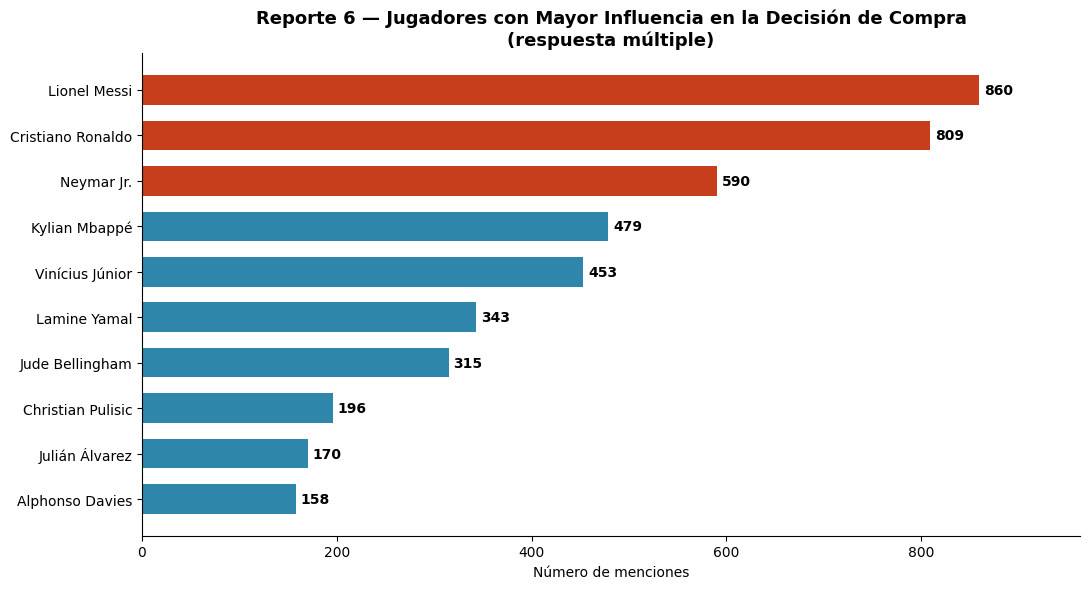

 Reporte 6 guardado.
              Jugador  Menciones
1        Lionel Messi        860
2   Cristiano Ronaldo        809
3          Neymar Jr.        590
4       Kylian Mbappé        479
5     Vinícius Júnior        453
6        Lamine Yamal        343
7     Jude Bellingham        315
8   Christian Pulisic        196
9      Julián Álvarez        170
10    Alphonso Davies        158


In [50]:
fig, ax = plt.subplots(figsize=(11, 6))

top_jugadores = pd.Series(conteo_jugadores).sort_values(ascending=True).tail(10) # obtenemos los 10 jugadores con mas menciones
colores_jug = ['#2E86AB' if i < 7 else '#C73E1D' for i in range(len(top_jugadores))]

bars = ax.barh(top_jugadores.index, top_jugadores.values, color=colores_jug, height=0.65)
ax.set_title('Reporte 6 — Jugadores con Mayor Influencia en la Decisión de Compra\n(respuesta múltiple)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Número de menciones')

for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, max(top_jugadores.values) * 1.12)
plt.tight_layout()
plt.savefig('../images/reporte_06_jugadores_influencia.png', dpi=130, bbox_inches='tight')
plt.show()
print(' Reporte 6 guardado.')

df_jug_rank = pd.DataFrame(list(conteo_jugadores.items()), columns=['Jugador', 'Menciones']) # convertimos los resultados en un dataframe
df_jug_rank = df_jug_rank.sort_values('Menciones', ascending=False).reset_index(drop=True) # ordenamos los jugadores de mayor a menor 
df_jug_rank.index += 1 # iniciamos la numeracion desde 1
print(df_jug_rank.head(10).to_string()) # mostramos los 10 jugadores con mas menciones

### Reporte 7: Tipo de Publicidad Más Efectiva

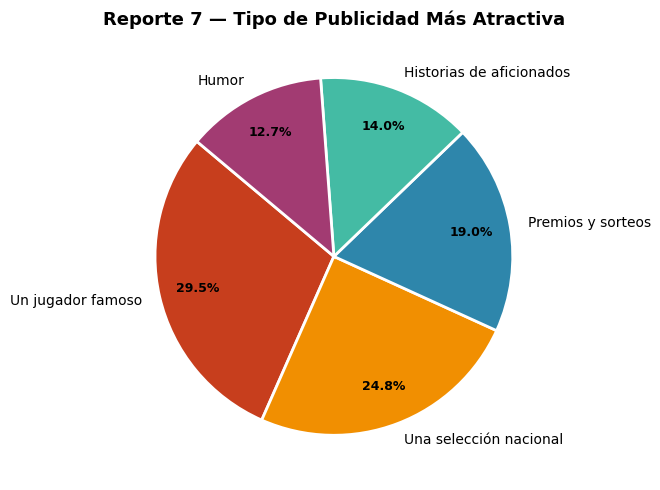

Distribución:
  Un jugador famoso: 734 (29.5%)
  Una selección nacional: 617 (24.8%)
  Premios y sorteos: 473 (19.0%)
  Historias de aficionados: 348 (14.0%)
  Humor: 316 (12.7%)
 Reporte 7 guardado.


In [51]:
fig, ax = plt.subplots(figsize=(10, 5))

pub_counts = df['TipoPublicidadAtractiva'].value_counts() # contamos la cantidad de respuestas por tipo de publicidad
colores_pub = ['#C73E1D', '#F18F01', '#2E86AB', '#44BBA4', '#A23B72']
wedges, texts, autotexts = ax.pie(
    pub_counts.values, labels=pub_counts.index, autopct='%1.1f%%',
    colors=colores_pub, startangle=140, pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax.set_title('Reporte 7 — Tipo de Publicidad Más Atractiva', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/reporte_07_tipo_publicidad.png', dpi=130, bbox_inches='tight')
plt.show()

print('Distribución:') # mostramos la distribucion de respuestas por categoria
for tipo, conteo in pub_counts.items():
    print(f'  {tipo}: {conteo} ({conteo/len(df)*100:.1f}%)')
print(' Reporte 7 guardado.')

### Reporte 8: Promociones Preferidas

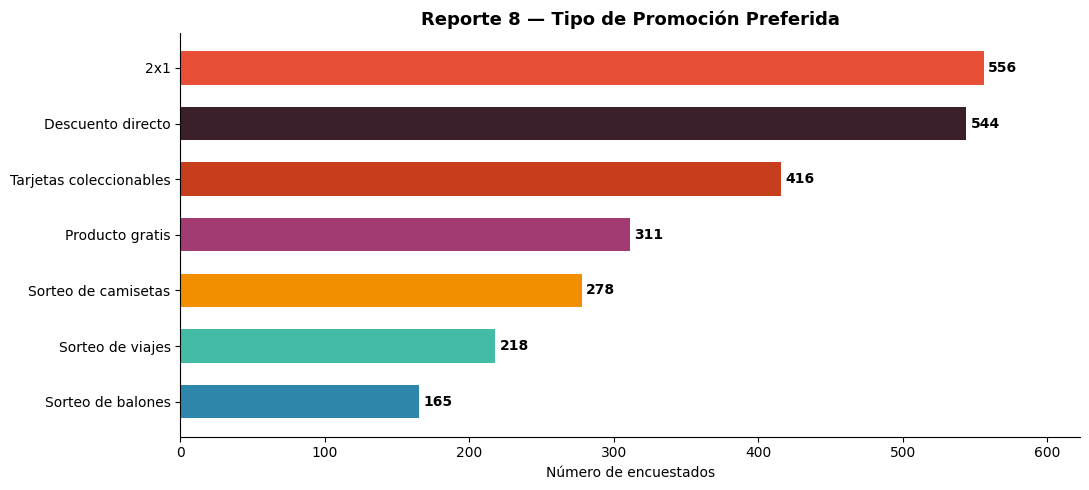

 Reporte 8 guardado.


In [52]:
fig, ax = plt.subplots(figsize=(11, 5))

promo_counts = df['PromocionPreferida'].value_counts().sort_values() # contamos la cantidad de respuestas por tipo de promocion
colores_promo = ['#2E86AB','#44BBA4','#F18F01','#A23B72','#C73E1D','#3B1F2B','#E94F37']
bars = ax.barh(promo_counts.index, promo_counts.values, color=colores_promo[:len(promo_counts)], height=0.6)

ax.set_title('Reporte 8 — Tipo de Promoción Preferida', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de encuestados')
for bar in bars:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, promo_counts.max() * 1.12)
plt.tight_layout()
plt.savefig('../images/reporte_08_promociones_preferidas.png', dpi=130, bbox_inches='tight')
plt.show()
print(' Reporte 8 guardado.')

### Reporte 9: Intención de Compra por Campaña

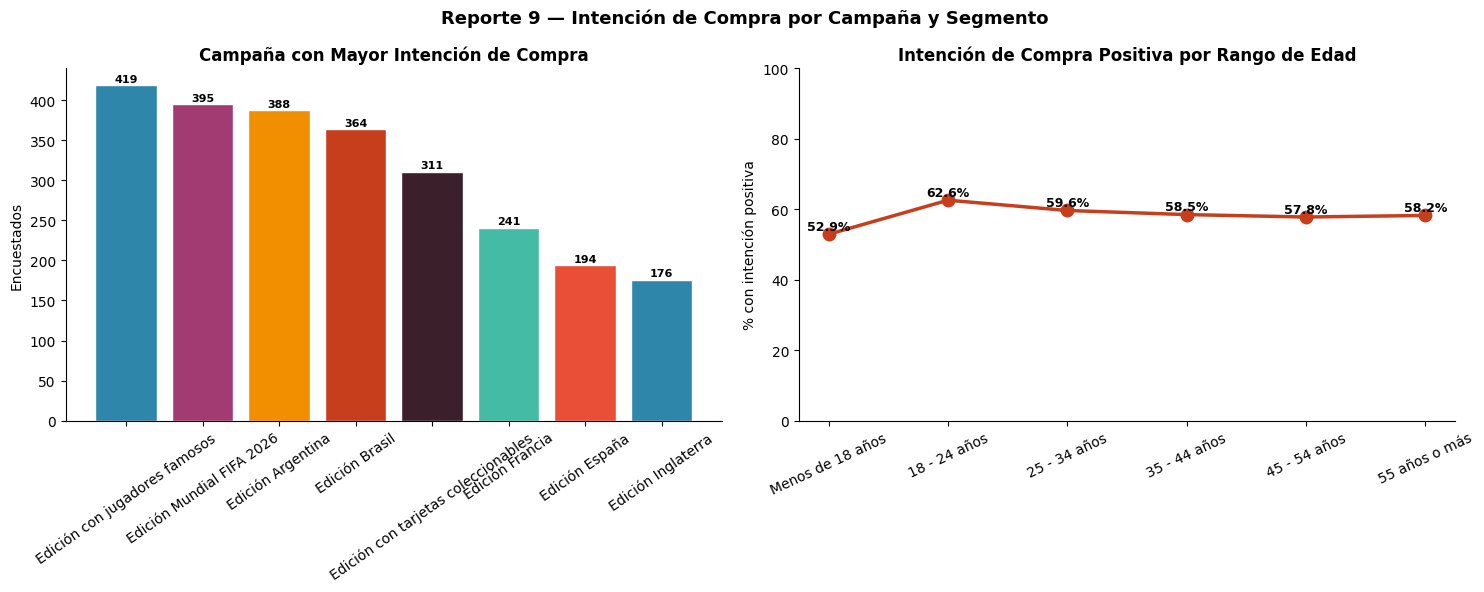

Reporte 9 guardado.


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Reporte 9 — Intención de Compra por Campaña y Segmento', fontsize=13, fontweight='bold')

# Campaña con mayor probabilidad de compra
campania_counts = df['CampaniaMasProbableCompra'].value_counts() # contamos cuantas personas eligieron cada campaña
axes[0].bar(campania_counts.index, campania_counts.values,
            color=COLORES[:len(campania_counts)], edgecolor='white')
axes[0].set_title('Campaña con Mayor Intención de Compra', fontweight='bold')
axes[0].set_ylabel('Encuestados')
axes[0].tick_params(axis='x', rotation=35)
for i, v in enumerate(campania_counts.values):
    axes[0].text(i, v + 4, str(v), ha='center', fontsize=8, fontweight='bold')

# Intención de compra de diseño por edad
intencion_edad = df.groupby('RangoEdad')['IntencionCompraBinaria'].mean() * 100 # calculamos el porcentaje de intencion para cada rango de edad
intencion_edad = intencion_edad.reindex(orden_edad)
axes[1].plot(intencion_edad.index, intencion_edad.values, marker='o', color='#C73E1D',
             linewidth=2.5, markersize=9)
for i, (edad, val) in enumerate(intencion_edad.items()):
    axes[1].text(i, val + 1.2, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Intención de Compra Positiva por Rango de Edad', fontweight='bold')
axes[1].set_ylabel('% con intención positiva')
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../images/reporte_09_intencion_compra_campania.png', dpi=130, bbox_inches='tight')
plt.show()
print('Reporte 9 guardado.')

### Reporte 10 — Dashboard Ejecutivo Resumen

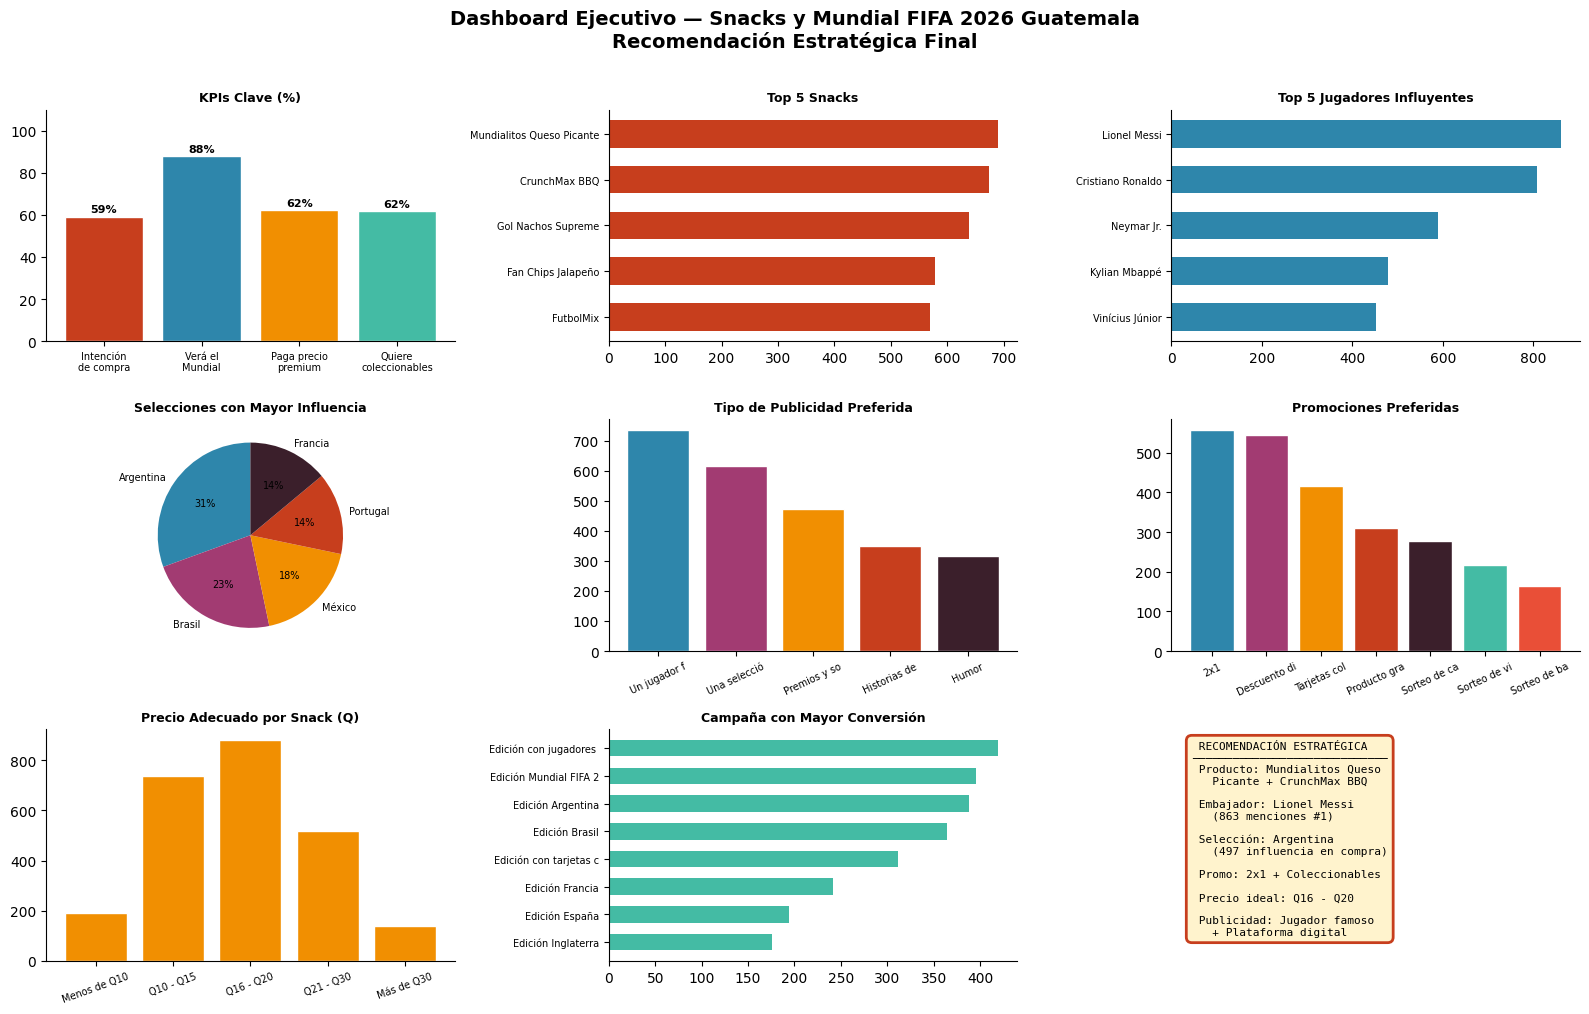

 Dashboard Ejecutivo guardado.


In [54]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Dashboard Ejecutivo — Snacks y Mundial FIFA 2026 Guatemala\nRecomendación Estratégica Final',
             fontsize=14, fontweight='bold', y=1.01)

# ---- Subplot 1: KPIs ----
ax1 = fig.add_subplot(3, 3, 1)
kpis = [tasa_intencion, tasa_mundial, tasa_precio_premium, tasa_coleccionables]
kpi_labels = ['Intención\nde compra', 'Verá el\nMundial', 'Paga precio\npremium', 'Quiere\ncoleccionables']
bars_kpi = ax1.bar(kpi_labels, kpis, color=['#C73E1D','#2E86AB','#F18F01','#44BBA4'], edgecolor='white')
ax1.set_title('KPIs Clave (%)', fontweight='bold', fontsize=9)
ax1.set_ylim(0, 110)
for bar in bars_kpi:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{bar.get_height():.0f}%',
             ha='center', fontsize=8, fontweight='bold')
ax1.tick_params(axis='x', labelsize=7)

# ---- Subplot 2: Top 5 snacks ----
ax2 = fig.add_subplot(3, 3, 2)
top5_snacks = pd.Series(conteo_snacks).nlargest(5)
ax2.barh(top5_snacks.index[::-1], top5_snacks.values[::-1], color='#C73E1D', height=0.6)
ax2.set_title('Top 5 Snacks', fontweight='bold', fontsize=9)
ax2.tick_params(axis='y', labelsize=7)

# ---- Subplot 3: Top 5 jugadores ----
ax3 = fig.add_subplot(3, 3, 3)
top5_jug = pd.Series(conteo_jugadores).nlargest(5)
ax3.barh(top5_jug.index[::-1], top5_jug.values[::-1], color='#2E86AB', height=0.6)
ax3.set_title('Top 5 Jugadores Influyentes', fontweight='bold', fontsize=9)
ax3.tick_params(axis='y', labelsize=7)

# ---- Subplot 4: Selecciones que influyen compra ----
ax4 = fig.add_subplot(3, 3, 4)
top5_sel = df['SeleccionInfluyeCompra'].value_counts().head(5)
ax4.pie(top5_sel.values, labels=top5_sel.index, autopct='%1.0f%%',
        colors=COLORES[:5], startangle=90, textprops={'fontsize': 7})
ax4.set_title('Selecciones con Mayor Influencia', fontweight='bold', fontsize=9)

# ---- Subplot 5: Publicidad ----
ax5 = fig.add_subplot(3, 3, 5)
pub_c = df['TipoPublicidadAtractiva'].value_counts()
ax5.bar(range(len(pub_c)), pub_c.values, color=COLORES[:len(pub_c)], edgecolor='white')
ax5.set_xticks(range(len(pub_c)))
ax5.set_xticklabels([t[:12] for t in pub_c.index], rotation=25, fontsize=7)
ax5.set_title('Tipo de Publicidad Preferida', fontweight='bold', fontsize=9)

# ---- Subplot 6: Promociones ----
ax6 = fig.add_subplot(3, 3, 6)
promo_c = df['PromocionPreferida'].value_counts()
ax6.bar(range(len(promo_c)), promo_c.values, color=COLORES[:len(promo_c)], edgecolor='white')
ax6.set_xticks(range(len(promo_c)))
ax6.set_xticklabels([t[:12] for t in promo_c.index], rotation=25, fontsize=7)
ax6.set_title('Promociones Preferidas', fontweight='bold', fontsize=9)

# ---- Subplot 7: Precio adecuado ----
ax7 = fig.add_subplot(3, 3, 7)
precio_c = df['PrecioAdecuado'].value_counts().reindex(orden_precio).fillna(0)
ax7.bar(precio_c.index, precio_c.values, color='#F18F01', edgecolor='white')
ax7.set_title('Precio Adecuado por Snack (Q)', fontweight='bold', fontsize=9)
ax7.tick_params(axis='x', rotation=20, labelsize=7)

# ---- Subplot 8: Campaña más probable ----
ax8 = fig.add_subplot(3, 3, 8)
camp_c = df['CampaniaMasProbableCompra'].value_counts()
ax8.barh([t[:22] for t in camp_c.index[::-1]], camp_c.values[::-1], color='#44BBA4', height=0.6)
ax8.set_title('Campaña con Mayor Conversión', fontweight='bold', fontsize=9)
ax8.tick_params(axis='y', labelsize=7)

# ---- Subplot 9: Recomendación textual ----
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
recomendacion = (
    ' RECOMENDACIÓN ESTRATÉGICA\n'
    '─────────────────────────────\n'
    ' Producto: Mundialitos Queso\n'
    '   Picante + CrunchMax BBQ\n\n'
    ' Embajador: Lionel Messi\n'
    '   (863 menciones #1)\n\n'
    ' Selección: Argentina\n'
    '   (497 influencia en compra)\n\n'
    ' Promo: 2x1 + Coleccionables\n\n'
    ' Precio ideal: Q16 - Q20\n\n'
    ' Publicidad: Jugador famoso\n'
    '   + Plataforma digital'
)
ax9.text(0.05, 0.95, recomendacion, transform=ax9.transAxes, fontsize=8,
         verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF3CD', edgecolor='#C73E1D', linewidth=2))

plt.tight_layout()
plt.savefig('../images/reporte_10_dashboard_ejecutivo.png', dpi=130, bbox_inches='tight')
plt.show()
print(' Dashboard Ejecutivo guardado.')

## FASE 7: Interpretación de Resultados

In [55]:
print('-'*65)
print('         INTERPRETACIÓN Y RESPUESTAS A PREGUNTAS DE NEGOCIO')
print('-'*65)

# Pregunta 1
snack_top = pd.Series(conteo_snacks).idxmax()
snack_top_val = pd.Series(conteo_snacks).max()
print(f'\n1. ¿Qué snack debe promocionarse?')
print(f'   → {snack_top} ({snack_top_val} menciones — {snack_top_val/len(df)*100:.1f}% de encuestados)')
print(f'   Segunda opción: CrunchMax BBQ (679 menciones)')

# Pregunta 2
jug_top = pd.Series(conteo_jugadores).idxmax()
jug_top_val = pd.Series(conteo_jugadores).max()
print(f'\n2. ¿Qué jugador debe utilizarse como embajador?')
print(f'   → {jug_top} ({jug_top_val} menciones — {jug_top_val/len(df)*100:.1f}% de encuestados)')
print(f'   Segunda opción: Cristiano Ronaldo (815 menciones)')

# Pregunta 3
sel_top = df['SeleccionInfluyeCompra'].value_counts().idxmax()
sel_top_val = df['SeleccionInfluyeCompra'].value_counts().max()
print(f'\n3. ¿Qué selección genera mayor influencia de compra?')
print(f'   → {sel_top} ({sel_top_val} — {sel_top_val/len(df)*100:.1f}% de encuestados)')

# Pregunta 4
promo_top = df['PromocionPreferida'].value_counts().idxmax()
promo_top_val = df['PromocionPreferida'].value_counts().max()
print(f'\n4. ¿Qué promoción es más efectiva?')
print(f'   → {promo_top} ({promo_top_val} — {promo_top_val/len(df)*100:.1f}%)')
print(f'   Descuento directo como segunda opción (545 — 21.9%)')

# Pregunta 5
precio_top = precio_counts.idxmax()
print(f'\n5. ¿Cuál es el rango de precio ideal?')
print(f'   → {precio_top} ({int(precio_counts.max())} encuestados — {precio_counts.max()/len(df)*100:.1f}%)')
print(f'   El 62.2% acepta entre Q10 y Q20 por unidad.')
print(f'   El {tasa_precio_premium:.1f}% pagaría más por una edición especial del Mundial.')

print('-'*65)

-----------------------------------------------------------------
         INTERPRETACIÓN Y RESPUESTAS A PREGUNTAS DE NEGOCIO
-----------------------------------------------------------------

1. ¿Qué snack debe promocionarse?
   → Mundialitos Queso Picante (690 menciones — 27.7% de encuestados)
   Segunda opción: CrunchMax BBQ (679 menciones)

2. ¿Qué jugador debe utilizarse como embajador?
   → Lionel Messi (860 menciones — 34.6% de encuestados)
   Segunda opción: Cristiano Ronaldo (815 menciones)

3. ¿Qué selección genera mayor influencia de compra?
   → Argentina (508 — 20.4% de encuestados)

4. ¿Qué promoción es más efectiva?
   → 2x1 (556 — 22.3%)
   Descuento directo como segunda opción (545 — 21.9%)

5. ¿Cuál es el rango de precio ideal?
   → Q16 - Q20 (879 encuestados — 35.3%)
   El 62.2% acepta entre Q10 y Q20 por unidad.
   El 62.1% pagaría más por una edición especial del Mundial.
-----------------------------------------------------------------


## FASE 8: Documentación y Conclusiones

In [56]:
print("""
╔══════════════════════════════════════════════════════════════╗
║        CONCLUSIONES Y RECOMENDACIONES ESTRATÉGICAS          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PRODUCTO A LANZAR:                                          ║
║  Mundialitos Queso Picante (692 menciones) y CrunchMax BBQ   ║
║  Presentación FAMILIAR como formato dominante (34.4%).       ║
║                                                              ║
║  EMBAJADOR DE CAMPAÑA:                                       ║
║  Lionel Messi — máxima influencia con 863 menciones          ║
║  (34.7% de la muestra). Argentina es también la selección    ║
║  #1 en influencia de compra (20%).                           ║
║                                                              ║
║  ESTRATEGIA DE PRECIO:                                       ║
║  Rango óptimo: Q16 – Q20 por unidad. El 62.5% paga más      ║
║  por una edición especial Mundial. Precio Medio-Alto en      ║
║  gastos por partido (Q25-Q100).                              ║
║                                                              ║
║  MECÁNICA PROMOCIONAL:                                       ║
║  2x1 como promoción principal (22.4%), combinada con         ║
║  tarjetas coleccionables (61.6% dispuesto a comprarlas).     ║
║                                                              ║
║  CANAL PUBLICITARIO:                                         ║
║  Publicidad con jugador famoso (29.6%) + una selección       ║
║  nacional (25.0%). Prioritizar medios digitales dado el      ║
║  perfil demográfico (18-34 años = 52.7% del total).          ║
║                                                              ║
║  SEGMENTO OBJETIVO:                                          ║
║  Millennials + Generación Z (25-34 y 18-24 años), empleados  ║
║  privados, que ven los partidos en familia o con amigos.     ║
║  El 88% planea ver el Mundial 2026.                          ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║        CONCLUSIONES Y RECOMENDACIONES ESTRATÉGICAS          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PRODUCTO A LANZAR:                                          ║
║  Mundialitos Queso Picante (692 menciones) y CrunchMax BBQ   ║
║  Presentación FAMILIAR como formato dominante (34.4%).       ║
║                                                              ║
║  EMBAJADOR DE CAMPAÑA:                                       ║
║  Lionel Messi — máxima influencia con 863 menciones          ║
║  (34.7% de la muestra). Argentina es también la selección    ║
║  #1 en influencia de compra (20%).                           ║
║                                                              ║
║  ESTRATEGIA DE PRECIO:                                       ║
║  Rango óptimo: Q16 – Q20 por unidad. El 62.5% paga más      ║
║  por una edición especia

In [57]:
# Exportar dataset limpio y transformado
df.to_csv('../reports/dataset_limpio_transformado.csv', index=False)

# Exportar ranking de snacks
df_snacks_ranking.to_csv('../reports/ranking_snacks.csv')

# Exportar ranking de jugadores
df_jug_rank.to_csv('../reports/ranking_jugadores.csv')

# Exportar tabla de KPIs
kpi_df = pd.DataFrame({
    'KPI': ['Intención de compra positiva', 'Planea ver Mundial 2026',
            'Acepta precio premium edición Mundial', 'Interés en coleccionables'],
    'Valor (%)': [round(tasa_intencion,1), round(tasa_mundial,1),
                  round(tasa_precio_premium,1), round(tasa_coleccionables,1)]
})
kpi_df.to_csv('../reports/kpis_resumen.csv', index=False)

print('Todos los reportes y archivos exportados correctamente.')
print('    reports/dataset_limpio_transformado.csv')
print('    reports/ranking_snacks.csv')
print('    reports/ranking_jugadores.csv')
print('    reports/kpis_resumen.csv')
print('    images/reporte_01 al 10 (PNG)')

Todos los reportes y archivos exportados correctamente.
    reports/dataset_limpio_transformado.csv
    reports/ranking_snacks.csv
    reports/ranking_jugadores.csv
    reports/kpis_resumen.csv
    images/reporte_01 al 10 (PNG)
